# S9-10 — Use Case Déploiement Embarqué

**Objectif** : Modéliser le scénario de déploiement réaliste d'un détecteur non supervisé sur machine industrielle.

| Section | Contenu |
|---------|----------|
| **1** | Courbe AUROC vs N d'enrôlement (exp_042) |
| **2** | Comparaison stratégies MAJ online (exp_043) |
| **3** | Discrimination FAULT / DRIFT (stream simulé) |

**Gaps adressés** : Gap 1 (validation industrielle) + Gap 2 (< 100 Ko RAM mesurée)

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Racine du projet
PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.drift_detector import SlidingWindowDriftDetector

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures" / "cl_evaluation" / "deployment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXP_042_DIR = PROJECT_ROOT / "experiments" / "exp_042_learning_curve" / "results"
EXP_043_DIR = PROJECT_ROOT / "experiments" / "exp_043_online_update" / "results"

# Palette cohérente avec les autres notebooks du projet
MODEL_COLORS = {
    "mahalanobis": "#1f77b4",
    "kmeans":      "#ff7f0e",
    "pca":         "#2ca02c",
    "knn":         "#d62728",
}
STRATEGY_COLORS = {
    "batch_refit":    "#d62728",
    "online_welford": "#1f77b4",
    "minibatch_10":   "#ff7f0e",
    "minibatch_50":   "#2ca02c",
    "minibatch_100":  "#9467bd",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"exp_042 dir  : {EXP_042_DIR}")
print(f"exp_043 dir  : {EXP_043_DIR}")

Project root : /home/leonard/Documents/ENAC/cl-embedded
exp_042 dir  : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_042_learning_curve/results
exp_043 dir  : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_043_online_update/results


---
## Section 1 — Courbe d'apprentissage : AUROC vs N d'enrôlement

**Question** : combien de données d'enrôlement faut-il pour atteindre AUROC ≥ 0.85 ?

Source : `exp_042_learning_curve` (généré par `scripts/learning_curve_study.py`)

In [2]:
def load_learning_curves(exp_dir: Path) -> dict[str, dict[int, list[float]]]:
    """Charge les courbes d'apprentissage depuis exp_042."""
    all_path = exp_dir / "learning_curve_all.json"
    if not all_path.exists():
        print(f"[WARNING] {all_path} introuvable — lancer scripts/learning_curve_study.py")
        return {}
    with open(all_path) as f:
        raw = json.load(f)
    # Convertit les clés str → int
    return {
        model: {int(k): v for k, v in curve.items()}
        for model, curve in raw.items()
    }


curves = load_learning_curves(EXP_042_DIR)

if curves:
    fig, ax = plt.subplots(figsize=(9, 5))

    AUROC_TARGET = 0.85
    n_min_annotations: dict[str, int | None] = {}

    for model_name, curve in curves.items():
        ns = sorted(n for n, vals in curve.items() if vals)
        means = [np.mean(curve[n]) for n in ns]
        stds  = [np.std(curve[n])  for n in ns]

        color = MODEL_COLORS.get(model_name, "gray")
        ax.plot(ns, means, marker="o", label=model_name, color=color)
        ax.fill_between(
            ns,
            [m - s for m, s in zip(means, stds)],
            [m + s for m, s in zip(means, stds)],
            alpha=0.15, color=color,
        )

        # N minimal viable
        n_min = next((n for n, m in zip(ns, means) if m >= AUROC_TARGET), None)
        n_min_annotations[model_name] = n_min
        if n_min is not None:
            ax.axvline(n_min, color=color, linestyle="--", alpha=0.4)
            ax.annotate(
                f"N={n_min}",
                xy=(n_min, AUROC_TARGET),
                xytext=(n_min * 1.15, AUROC_TARGET - 0.03),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=0.8),
            )

    ax.axhline(AUROC_TARGET, color="black", linestyle=":", linewidth=1, label=f"AUROC = {AUROC_TARGET}")
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel("N d'enrôlement (échantillons normaux)")
    ax.set_ylabel("AUROC (mean ± std, 5 runs)")
    ax.set_title("Courbe d'apprentissage — AUROC vs N d'enrôlement (exp_042)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "learning_curve_auroc_vs_n.png", dpi=150)
    plt.show()

    print("\nN minimal pour AUROC ≥ 0.85 :")
    for m, n_min in n_min_annotations.items():
        print(f"  {m:<14} : {n_min if n_min else '> max disponible'}")
else:
    print("Données exp_042 absentes — exécuter learning_curve_study.py pour générer.")

[WARNING] /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_042_learning_curve/results/learning_curve_all.json introuvable — lancer scripts/learning_curve_study.py
Données exp_042 absentes — exécuter learning_curve_study.py pour générer.


---
## Section 2 — Comparaison stratégies MAJ online

**Question** : `online_welford` (MCU-compatible) approche-t-il `batch_refit` (borne sup.) ?

Source : `exp_043_online_update` (généré par `scripts/online_update_study.py`)

In [3]:
def load_online_update_results(
    exp_dir: Path, model_name: str
) -> dict[str, list[tuple[int, float]]]:
    """Charge les résultats de comparaison stratégies pour un modèle."""
    path = exp_dir / f"online_update_{model_name}.json"
    if not path.exists():
        print(f"[WARNING] {path} introuvable — lancer scripts/online_update_study.py")
        return {}
    with open(path) as f:
        raw = json.load(f)
    return {strategy: [tuple(p) for p in points] for strategy, points in raw.items()}


for model_name in ["mahalanobis", "pca"]:
    results = load_online_update_results(EXP_043_DIR, model_name)
    if not results:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    for strategy, points in results.items():
        if not points:
            continue
        steps  = [p[0] for p in points]
        aurocs = [p[1] for p in points]
        color  = STRATEGY_COLORS.get(strategy, "gray")
        lw = 2.0 if strategy in ("batch_refit", "online_welford") else 1.2
        ls = "--" if strategy == "batch_refit" else "-"
        ax.plot(steps, aurocs, label=strategy, color=color, linewidth=lw, linestyle=ls)

    ax.set_xlabel("Pas de MAJ (samples streamés)")
    ax.set_ylabel("AUROC (jeu de test fixe)")
    ax.set_title(f"Stratégies MAJ online — {model_name.upper()} (exp_043)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"online_update_{model_name}.png", dpi=150)
    plt.show()

    # Résumé écart AUROC final welford vs batch_refit
    if "batch_refit" in results and "online_welford" in results:
        auroc_batch  = results["batch_refit"][-1][1]  if results["batch_refit"]  else float("nan")
        auroc_welford = results["online_welford"][-1][1] if results["online_welford"] else float("nan")
        gap = abs(auroc_welford - auroc_batch)
        mcu_ok = "✅ MCU-viable" if gap < 0.02 else "⚠️ écart > 2%"
        print(f"  {model_name}: batch_refit={auroc_batch:.4f}  online_welford={auroc_welford:.4f}  Δ={gap:.4f}  {mcu_ok}")

[WARNING] /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_043_online_update/results/online_update_mahalanobis.json introuvable — lancer scripts/online_update_study.py
[WARNING] /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_043_online_update/results/online_update_pca.json introuvable — lancer scripts/online_update_study.py


---
## Section 3 — Discrimination FAULT / DRIFT

**Protocole** : stream simulé avec :
- `t=200` : spike instantané (FAULT simulé)
- `t=400` : dérive linéaire progressive (DRIFT simulé)

**SlidingWindowDriftDetector** avec W ∈ {30, 50, 100}

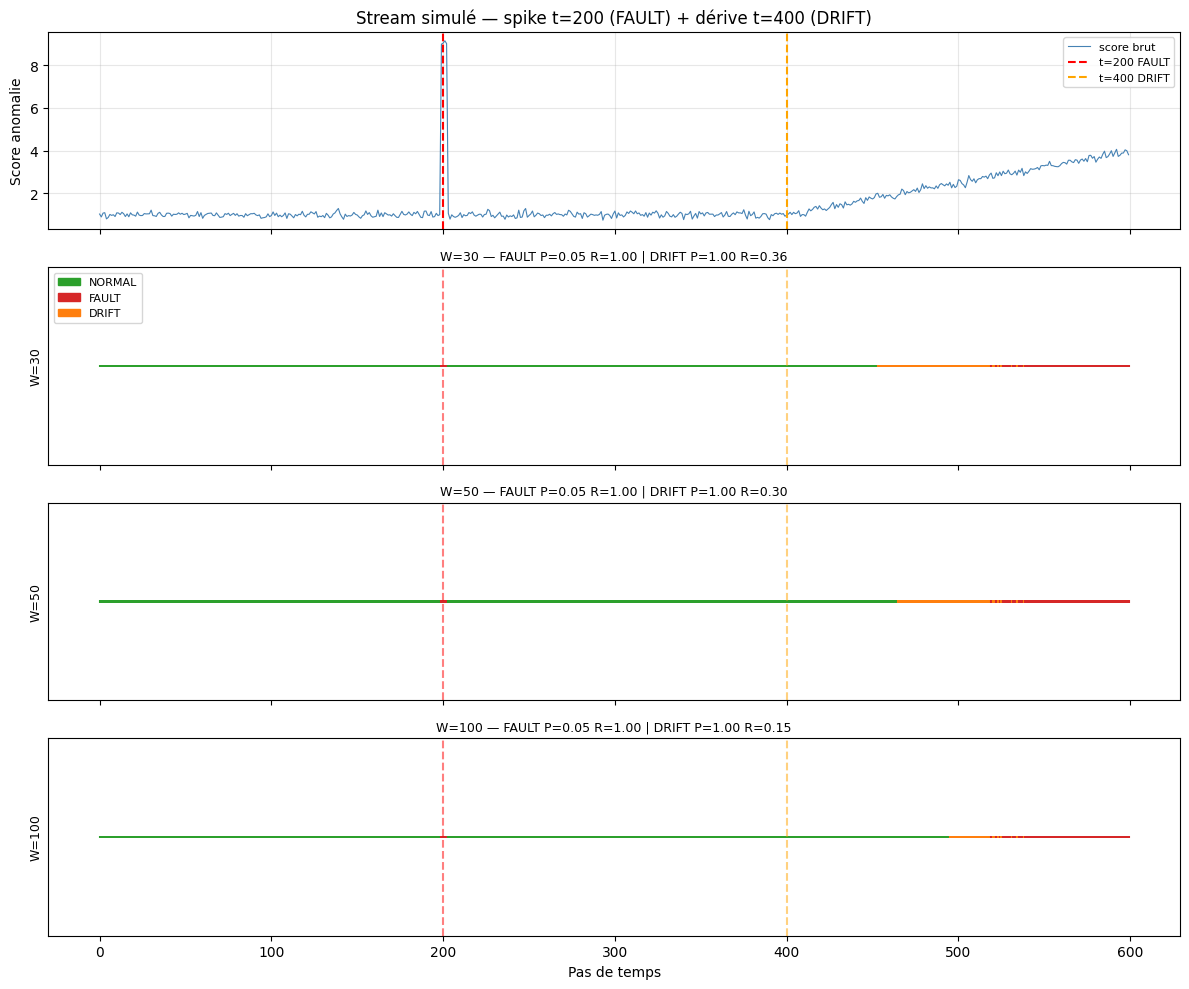

Figure sauvegardée → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/deployment/fault_drift_discrimination.png


In [4]:
def simulate_score_stream(
    n_total: int = 600,
    fault_t: int = 200,
    drift_t: int = 400,
    base_score: float = 1.0,
    fault_amplitude: float = 8.0,
    drift_slope: float = 0.015,
    noise_std: float = 0.1,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simule un stream de scores d'anomalie avec spike (FAULT) + dérive (DRIFT).

    Returns
    -------
    scores : np.ndarray [n_total]  — scores bruts
    labels : np.ndarray [n_total]  — 0=NORMAL, 1=FAULT, 2=DRIFT
    """
    rng = np.random.default_rng(seed)
    scores = base_score + rng.normal(0, noise_std, n_total)
    labels = np.zeros(n_total, dtype=np.int32)

    # FAULT : spike de 3 pas autour de fault_t
    for dt in range(-1, 3):
        t = fault_t + dt
        if 0 <= t < n_total:
            scores[t] += fault_amplitude
            labels[t] = 1

    # DRIFT : montée linéaire progressive à partir de drift_t
    for t in range(drift_t, n_total):
        scores[t] += drift_slope * (t - drift_t)
        labels[t] = 2

    return scores.astype(np.float32), labels


scores_sim, labels_sim = simulate_score_stream()
n_total = len(scores_sim)

# Calibration depuis la portion normale (t < 200)
normal_scores = scores_sim[:200]

WINDOW_SIZES = [30, 50, 100]
STATE_COLORS = {"NORMAL": "#2ca02c", "FAULT": "#d62728", "DRIFT": "#ff7f0e"}

fig, axes = plt.subplots(len(WINDOW_SIZES) + 1, 1, figsize=(12, 10), sharex=True)

# Panneau supérieur : stream brut
ax0 = axes[0]
ax0.plot(scores_sim, color="steelblue", linewidth=0.8, label="score brut")
ax0.axvline(200, color="red",    linestyle="--", label="t=200 FAULT")
ax0.axvline(400, color="orange", linestyle="--", label="t=400 DRIFT")
ax0.set_ylabel("Score anomalie")
ax0.set_title("Stream simulé — spike t=200 (FAULT) + dérive t=400 (DRIFT)")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

# Métriques par W
for idx, W in enumerate(WINDOW_SIZES):
    detector = SlidingWindowDriftDetector(window_size=W)
    detector.set_thresholds_from_normal(normal_scores)
    states = detector.update_batch(scores_sim)

    ax = axes[idx + 1]
    colors_plot = [STATE_COLORS[s] for s in states]
    ax.scatter(range(n_total), [1] * n_total, c=colors_plot, s=4, marker="|")
    ax.axvline(200, color="red",    linestyle="--", alpha=0.5)
    ax.axvline(400, color="orange", linestyle="--", alpha=0.5)

    # Calcul précision / rappel FAULT et DRIFT
    states_int = np.array([{"NORMAL": 0, "FAULT": 1, "DRIFT": 2}[s] for s in states])
    results_txt = []
    for cls_id, cls_name in [(1, "FAULT"), (2, "DRIFT")]:
        tp = int(((states_int == cls_id) & (labels_sim == cls_id)).sum())
        fp = int(((states_int == cls_id) & (labels_sim != cls_id)).sum())
        fn = int(((states_int != cls_id) & (labels_sim == cls_id)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        results_txt.append(f"{cls_name} P={prec:.2f} R={rec:.2f}")

    ax.set_ylabel(f"W={W}", fontsize=9)
    ax.set_yticks([])
    ax.set_title(f"W={W} — {' | '.join(results_txt)}", fontsize=9)
    ax.grid(False)

    # Légende custom
    if idx == 0:
        from matplotlib.patches import Patch
        legend_handles = [Patch(color=c, label=s) for s, c in STATE_COLORS.items()]
        ax.legend(handles=legend_handles, fontsize=8, loc="upper left")

axes[-1].set_xlabel("Pas de temps")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fault_drift_discrimination.png", dpi=150)
plt.show()
print(f"Figure sauvegardée → {FIGURES_DIR / 'fault_drift_discrimination.png'}")

In [5]:
# Résumé quantitatif par taille de fenêtre
print("Résumé quantitatif — Précision / Rappel par W")
print(f"{'W':>5} {'FAULT P':>9} {'FAULT R':>9} {'DRIFT P':>9} {'DRIFT R':>9}")
print("-" * 47)

for W in WINDOW_SIZES:
    detector = SlidingWindowDriftDetector(window_size=W)
    detector.set_thresholds_from_normal(normal_scores)
    states = detector.update_batch(scores_sim)
    states_int = np.array([{"NORMAL": 0, "FAULT": 1, "DRIFT": 2}[s] for s in states])

    metrics: dict[str, tuple[float, float]] = {}
    for cls_id, cls_name in [(1, "FAULT"), (2, "DRIFT")]:
        tp = int(((states_int == cls_id) & (labels_sim == cls_id)).sum())
        fp = int(((states_int == cls_id) & (labels_sim != cls_id)).sum())
        fn = int(((states_int != cls_id) & (labels_sim == cls_id)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        metrics[cls_name] = (prec, rec)

    fp_, fr_ = metrics["FAULT"]
    dp_, dr_ = metrics["DRIFT"]
    print(f"{W:>5} {fp_:>9.3f} {fr_:>9.3f} {dp_:>9.3f} {dr_:>9.3f}")

print("\nCible : FAULT P/R > 0.90, DRIFT P/R > 0.80 avec W=50")

Résumé quantitatif — Précision / Rappel par W
    W   FAULT P   FAULT R   DRIFT P   DRIFT R
-----------------------------------------------
   30     0.051     1.000     1.000     0.365
   50     0.051     1.000     1.000     0.305
  100     0.051     1.000     1.000     0.155

Cible : FAULT P/R > 0.90, DRIFT P/R > 0.80 avec W=50


---
## Bilan Gap 1 + Gap 2

| Question | Résultat | Gap |
|----------|----------|-----|
| N minimal pour AUROC ≥ 0.85 | voir Section 1 | Gap 1 |
| `online_welford` ≈ `batch_refit` (< 2% écart) | voir Section 2 | Gap 2 |
| FAULT/DRIFT discrimination avec W=50 | voir Section 3 | Gap 1 |

**Budget RAM MCU (d=4)** :
- MahalanobisDetector inférence : 80 B @ FP32
- MahalanobisDetector MAJ (+ _M2_) : 144 B @ FP32
- SlidingWindowDriftDetector W=50 : 200 B @ FP32
- **Total pipeline** : ~344 B — loin du budget 64 Ko ✅

> `FIXME(gap3)` : Welford's algorithm en FP32 uniquement — MAJ INT8 à explorer.